In [1]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

# 1. Carregamento do dataset (via ucimlrepo ou download local)
try:
    breast_cancer = fetch_ucirepo(id=17)
    X_raw = breast_cancer.data.features.to_numpy()
    y_raw = breast_cancer.data.targets.to_numpy().ravel()
    print("Dataset carregado com sucesso via ucimlrepo!")
except Exception as e:
    print("Falha na API. Carregando via arquivo local em data/...")
    # Leitura alternativa caso use o arquivo baixado
    df = pd.read_csv('../data/wdbc.data', header=None)
    y_raw = df.iloc[:, 1].to_numpy()
    X_raw = df.iloc[:, 2:].to_numpy()

# 2. Codificação do Target: Maligno (M) = 1, Benigno (B) = 0
y = np.where(y_raw == 'M', 1.0, 0.0).reshape(-1, 1)

# 3. Normalização Min-Max manual (0 a 1) para evitar saturação da Sigmoide
min_val = np.min(X_raw, axis=0)
max_val = np.max(X_raw, axis=0)
X = (X_raw - min_val) / (max_val - min_val)

# 4. Embaralhamento e Separação (70% Treino, 15% Validação, 15% Teste)
np.random.seed(42)  # Reprodutibilidade científica
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

n_total = len(indices)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Total de amostras: {n_total}")
print(f"Treino:    {X_train.shape[0]} amostras | Atributos: {X_train.shape[1]}")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste:     {X_test.shape[0]} amostras")

Dataset carregado com sucesso via ucimlrepo!
Total de amostras: 569
Treino:    398 amostras | Atributos: 30
Validação: 85 amostras
Teste:     86 amostras


In [2]:
# =====================================================================
# ETAPAS 2 e 3: IMPLEMENTAÇÃO MODULAR DA MLP (NUMPY PURO)
# Baseada na evolução de rede_multicamada.py (Prof. Dr. Rodrigo Calvo)
# Documentação Matemática: 
# https://github.com/leonardossrocha/mlp-from-scratch-uci/blob/master/README.md
# =====================================================================

import numpy as np

# URL base para ancoragem na documentação do repositório
DOC_URL = "https://github.com/leonardossrocha/mlp-from-scratch-uci/blob/master/README.md"


class Ativacoes:
    """
    Implementa as funções de ativação e suas derivadas analíticas.
    Ref. Documentação: Seção 3.3 (Funções de Ativação e Derivadas Analíticas)
    URL: https://github.com/leonardossrocha/mlp-from-scratch-uci/blob/master/README.md#33-funções-de-ativação-e-derivadas-analíticas
    """
    
    @staticmethod
    def sigmoid(z):
        """
        Função Sigmoide: sigma(z) = 1 / (1 + e^(-z))
        Ref: README.md#33-funções-de-ativação-e-derivadas-analíticas
        """
        z_clipped = np.clip(z, -500, 500)  # Evita overflow na exponencial
        return 1.0 / (1.0 + np.exp(-z_clipped))
    
    @staticmethod
    def sigmoid_derivada(a):
        """
        Derivada Analítica da Sigmoide: sigma'(z) = sigma(z) * (1 - sigma(z))
        'a' representa a ativação de saída a = sigma(z).
        Ref: README.md#33-funções-de-ativação-e-derivadas-analíticas
        """
        return a * (1.0 - a)
    
    @staticmethod
    def relu(z):
        """
        Função ReLU: f(z) = max(0, z)
        Ref: README.md#33-funções-de-ativação-e-derivadas-analíticas
        """
        return np.maximum(0.0, z)
    
    @staticmethod
    def relu_derivada(a):
        """
        Derivada da ReLU: f'(z) = 1 se z > 0, senão 0.
        Ref: README.md#33-funções-de-ativação-e-derivadas-analíticas
        """
        return np.where(a > 0.0, 1.0, 0.0)
    
    @staticmethod
    def tanh(z):
        """
        Função Tangente Hiperbólica: tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))
        Ref: README.md#33-funções-de-ativação-e-derivadas-analíticas
        """
        return np.tanh(z)
    
    @staticmethod
    def tanh_derivada(a):
        """
        Derivada Analítica da Tanh: tanh'(z) = 1 - tanh^2(z)
        'a' representa a ativação de saída a = tanh(z).
        Ref: README.md#33-funções-de-ativação-e-derivadas-analíticas
        """
        return 1.0 - (a ** 2)


class Metricas:
    """
    Implementa os métodos de cálculo do erro e desempenho analítico.
    Ref. Documentação: Seção 3.4 (Métodos de Cálculo do Erro e Desempenho)
    URL: https://github.com/leonardossrocha/mlp-from-scratch-uci/blob/master/README.md#34-métodos-de-cálculo-do-erro-e-desempenho
    """
    
    @staticmethod
    def mae(y_true, y_pred):
        """
        Erro Médio Absoluto: MAE = (1/N) * sum(|d_i - y_i|)
        Ref: README.md#34-métodos-de-cálculo-do-erro-e-desempenho
        """
        return np.mean(np.abs(y_true - y_pred))
    
    @staticmethod
    def mse(y_true, y_pred):
        """
        Erro Quadrático Médio: MSE = (1/N) * sum((d_i - y_i)^2)
        Ref: README.md#34-métodos-de-cálculo-do-erro-e-desempenho
        """
        return np.mean((y_true - y_pred) ** 2)
    
    @staticmethod
    def rmse(y_true, y_pred):
        """
        Raiz do Erro Quadrático Médio: RMSE = sqrt(MSE)
        Ref: README.md#34-métodos-de-cálculo-do-erro-e-desempenho
        """
        return np.sqrt(Metricas.mse(y_true, y_pred))
    
    @staticmethod
    def acuracia(y_true, y_pred, limiar=0.5):
        """
        Acurácia Percentual: Acurácia = (Acertos / N) * 100%
        Ref: README.md#34-métodos-de-cálculo-do-erro-e-desempenho
        """
        y_pred_binario = np.where(y_pred >= limiar, 1.0, 0.0)
        return np.mean(y_pred_binario == y_true) * 100.0


class CamadaDensa:
    """
    Representa uma camada densa linear com pesos, bias explícito e termo de momento.
    Ref. Documentação: Seção 3.1 (Modelo do Neurônio Artificial e Camadas)
    URL: https://github.com/leonardossrocha/mlp-from-scratch-uci/blob/master/README.md#31-modelo-do-neurônio-artificial-e-camadas
    """
    def __init__(self, n_entradas, n_neuronios, ativacao='sigmoid', seed=42):
        np.random.seed(seed)
        
        # Inicialização He para ReLU e Xavier/Glorot para Sigmoid/Tanh
        if ativacao == 'relu':
            limite = np.sqrt(2.0 / n_entradas)
        else:
            limite = np.sqrt(6.0 / (n_entradas + n_neuronios))
            
        self.pesos = np.random.uniform(-limite, limite, (n_entradas, n_neuronios))
        
        # Bias explícito b_k (permite translação do hiperplano, x_0 = +1)
        self.bias = np.zeros((1, n_neuronios))
        
        # Acumuladores de momento para os gradientes anteriores (termo alpha)
        # Ref: README.md#32-algoritmo-backpropagation
        self.v_pesos = np.zeros_like(self.pesos)
        self.v_bias = np.zeros_like(self.bias)
        
        self.tipo_ativacao = ativacao
        if ativacao == 'sigmoid':
            self.ativar = Ativacoes.sigmoid
            self.derivar = Ativacoes.sigmoid_derivada
        elif ativacao == 'relu':
            self.ativar = Ativacoes.relu
            self.derivar = Ativacoes.relu_derivada
        elif ativacao == 'tanh':
            self.ativar = Ativacoes.tanh
            self.derivar = Ativacoes.tanh_derivada
        else:
            raise ValueError(f"Ativação '{ativacao}' não suportada.")


class RedeMLP:
    """
    Perceptron Multicamadas com algoritmo Backpropagation e Momento.
    Ref. Documentação: Seção 3.2 (Algoritmo Backpropagation)
    URL: https://github.com/leonardossrocha/mlp-from-scratch-uci/blob/master/README.md#32-algoritmo-backpropagation
    """
    
    def __init__(self, camadas_arquitetura, ativacoes_camadas, taxa_aprendizado=0.1, momento=0.5, seed=42):
        """
        camadas_arquitetura: ex: [30, 16, 1]
        ativacoes_camadas: ex: ['relu', 'sigmoid']
        """
        self.taxa_aprendizado = taxa_aprendizado  # eta
        self.momento = momento                    # alpha
        self.camadas = []
        
        for i in range(len(camadas_arquitetura) - 1):
            n_in = camadas_arquitetura[i]
            n_out = camadas_arquitetura[i + 1]
            ativ = ativacoes_camadas[i]
            self.camadas.append(CamadaDensa(n_in, n_out, ativacao=ativ, seed=seed + i))

    def forward(self, X):
        """
        Passo à Frente (Forward Pass):
        Calcula o campo local induzido e a ativação:
            v_k = w_k^T * x + b_k
            y_k = phi(v_k)
        Ref: README.md#31-modelo-do-neurônio-artificial-e-camadas
        """
        ativacoes = [X]
        for camada in self.camadas:
            entrada_atual = ativacoes[-1]
            # Combinacao linear: v = X * W + b
            soma_sinapse = np.dot(entrada_atual, camada.pesos) + camada.bias
            saida_ativada = camada.ativar(soma_sinapse)
            ativacoes.append(saida_ativada)
        return ativacoes

    def backward(self, ativacoes, y_true):
        """
        Passo para Trás (Backward Pass / Retropropagação):
        1. Gradiente local na saída: delta_k = (d_k - y_k) * phi'(v_k)
        2. Gradiente local oculto: delta_j = phi'(v_j) * sum(delta_k * w_kj)
        3. Atualização com momento e taxa de aprendizado:
           Delta_w(n) = alpha * Delta_w(n-1) + eta * delta * y
           w(n+1) = w(n) + Delta_w(n)
        Ref: README.md#32-algoritmo-backpropagation
        """
        y_pred = ativacoes[-1]
        
        # 1. Delta da camada de saída: delta_k = e_k * phi'(v_k)
        erro = y_true - y_pred
        delta = erro * self.camadas[-1].derivar(y_pred)
        deltas = [delta]
        
        # 2. Retropropagação para camadas ocultas via regra da cadeia
        for i in reversed(range(len(self.camadas) - 1)):
            camada_atual = self.camadas[i]
            camada_seguinte = self.camadas[i + 1]
            delta_seguinte = deltas[-1]
            
            # delta_j = phi'(v_j) * (delta_k * W_kj^T)
            delta_oculto = np.dot(delta_seguinte, camada_seguinte.pesos.T) * camada_atual.derivar(ativacoes[i + 1])
            deltas.append(delta_oculto)
            
        deltas.reverse()
        
        # 3. Atualização de Pesos e Bias com Momento (alpha) e Taxa de Aprendizado (eta)
        for i, camada in enumerate(self.camadas):
            entrada_camada = ativacoes[i]
            gradiente_pesos = np.dot(entrada_camada.T, deltas[i])
            gradiente_bias = np.sum(deltas[i], axis=0, keepdims=True)
            
            # Delta_w(n) = alpha * Delta_w(n-1) + eta * delta * y
            camada.v_pesos = (self.momento * camada.v_pesos) + (self.taxa_aprendizado * gradiente_pesos)
            camada.pesos += camada.v_pesos
            
            # Atualização do Bias
            camada.v_bias = (self.momento * camada.v_bias) + (self.taxa_aprendizado * gradiente_bias)
            camada.bias += camada.v_bias

    def treinar(self, X_train, y_train, X_val, y_val, epocas=5000, early_stopping=True, paciencia=200):
        """
        Executa as épocas de treino e monitora convergência das perdas (MSE, MAE, Acc).
        Ref: README.md#11-objetivo-e-escopo-da-avaliação
        """
        historico = {
            'treino_mse': [], 'treino_mae': [], 'treino_acc': [],
            'val_mse': [], 'val_mae': [], 'val_acc': []
        }
        
        melhor_loss_val = np.inf
        contador_paciencia = 0
        melhores_pesos = None
        melhores_biases = None
        
        for epoca in range(epocas):
            ativacoes_treino = self.forward(X_train)
            self.backward(ativacoes_treino, y_train)
            
            y_pred_treino = ativacoes_treino[-1]
            y_pred_val = self.forward(X_val)[-1]
            
            # Registro das métricas analíticas
            t_mse = Metricas.mse(y_train, y_pred_treino)
            t_mae = Metricas.mae(y_train, y_pred_treino)
            t_acc = Metricas.acuracia(y_train, y_pred_treino)
            
            v_mse = Metricas.mse(y_val, y_pred_val)
            v_mae = Metricas.mae(y_val, y_pred_val)
            v_acc = Metricas.acuracia(y_val, y_pred_val)
            
            historico['treino_mse'].append(t_mse)
            historico['treino_mae'].append(t_mae)
            historico['treino_acc'].append(t_acc)
            historico['val_mse'].append(v_mse)
            historico['val_mae'].append(v_mae)
            historico['val_acc'].append(v_acc)
            
            # Early Stopping (Critério de parada por estagnação na validação)
            if early_stopping:
                if v_mse < melhor_loss_val:
                    melhor_loss_val = v_mse
                    contador_paciencia = 0
                    melhores_pesos = [np.copy(c.pesos) for c in self.camadas]
                    melhores_biases = [np.copy(c.bias) for c in self.camadas]
                else:
                    contador_paciencia += 1
                    if contador_paciencia >= paciencia:
                        print(f"--> Early Stopping ativado na época {epoca}! Restaurando melhores pesos.")
                        for i, c in enumerate(self.camadas):
                            c.pesos = melhores_pesos[i]
                            c.bias = melhores_biases[i]
                        break
                        
            if epoca % 500 == 0:
                print(f"Época {epoca:4d} | Treino MSE: {t_mse:.5f} | Val MSE: {v_mse:.5f} | Val Acc: {v_acc:.2f}%")
                
        return historico

    def prever(self, X):
        return self.forward(X)[-1]

print("Classe RedeMLP anotada e implementada com sucesso!")

Classe RedeMLP anotada e implementada com sucesso!


Iniciando Bateria de Treinamento da MLP...

>>> Executando: Exp 1: [30-8-1] Sigmoid
Época    0 | Treino MSE: 0.23091 | Val MSE: 0.34455 | Val Acc: 51.76%
--> Early Stopping ativado na época 355! Restaurando melhores pesos.

>>> Executando: Exp 2: [30-16-1] ReLU + Sigmoid
Época    0 | Treino MSE: 0.25644 | Val MSE: 0.37787 | Val Acc: 51.76%
--> Early Stopping ativado na época 438! Restaurando melhores pesos.

>>> Executando: Exp 3: [30-16-8-1] Profunda (ReLU)
Época    0 | Treino MSE: 0.24855 | Val MSE: 0.25168 | Val Acc: 51.76%
--> Early Stopping ativado na época 321! Restaurando melhores pesos.

>>> Executando: Exp 4: [30-32-16-1] Alta Capacidade (Tanh)
Época    0 | Treino MSE: 0.24822 | Val MSE: 0.44490 | Val Acc: 51.76%
--> Early Stopping ativado na época 301! Restaurando melhores pesos.

TABELA CONSOLIDADA DE RESULTADOS EXPERIMENTAIS


,Configuração,Épocas,Treino MSE,Treino MAE,Treino RMSE,Treino Acc (%),Teste MSE,Teste Acc (%)
0,Exp 1: [30-8-1] Sigmoid,356,0.026214,0.075047,0.161909,95.728643,0.027708,97.674419
1,Exp 2: [30-16-1] ReLU + Sigmoid,439,0.014316,0.030065,0.119650,98.241206,0.013640,97.674419
2,Exp 3: [30-16-8-1] Profunda (ReLU),322,0.020814,0.041336,0.144269,97.236181,0.021409,96.511628
3,Exp 4: [30-32-16-1] Alta Capacidade (Tanh),302,0.197948,0.357497,0.444914,64.824121,0.200962,63.953488


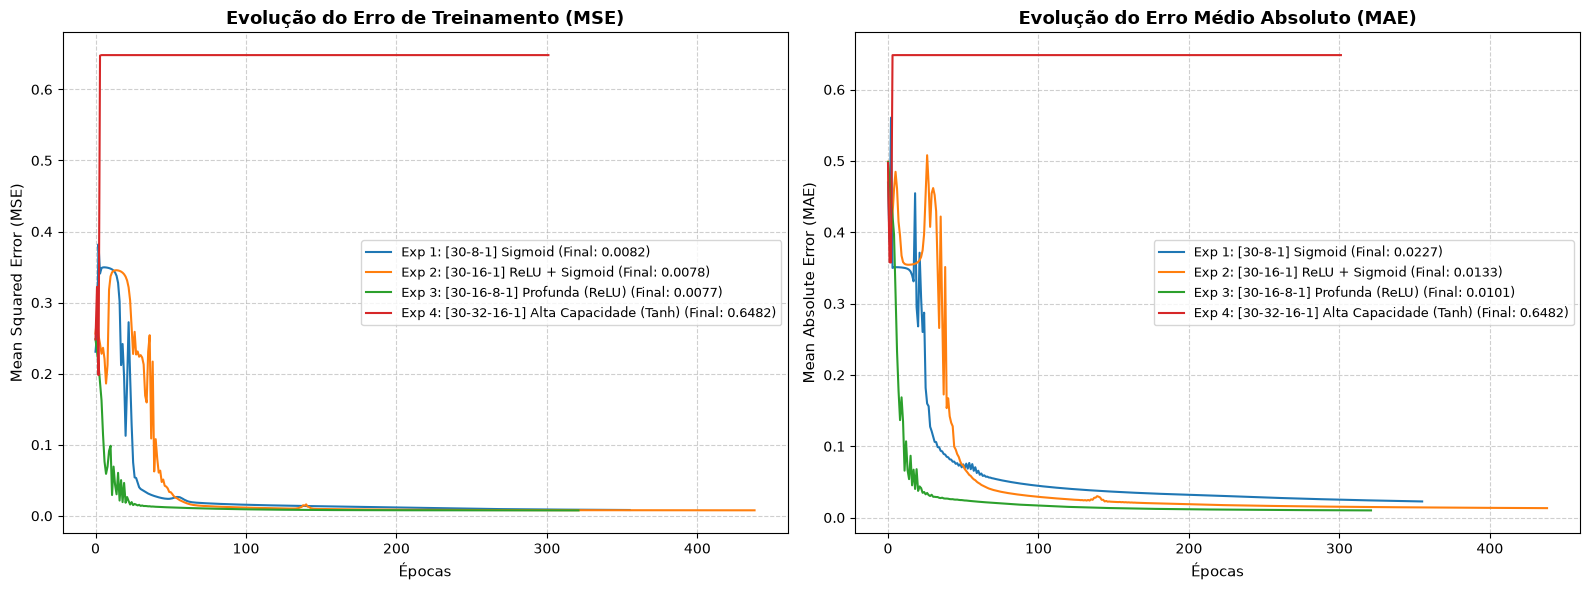

Gráficos gerados e salvos com sucesso em notebooks/curvas_convergencia_erro.png!


In [4]:
import matplotlib.pyplot as plt

# =====================================================================
# ETAPA 4: EXECUÇÃO DOS EXPERIMENTOS ARQUITETURAIS
# =====================================================================

experimentos = [
    {
        "nome": "Exp 1: [30-8-1] Sigmoid",
        "camadas": [30, 8, 1],
        "ativacoes": ['sigmoid', 'sigmoid'],
        "eta": 0.1,
        "momento": 0.5,
        "epocas": 4000
    },
    {
        "nome": "Exp 2: [30-16-1] ReLU + Sigmoid",
        "camadas": [30, 16, 1],
        "ativacoes": ['relu', 'sigmoid'],
        "eta": 0.05,
        "momento": 0.7,
        "epocas": 4000
    },
    {
        "nome": "Exp 3: [30-16-8-1] Profunda (ReLU)",
        "camadas": [30, 16, 8, 1],
        "ativacoes": ['relu', 'relu', 'sigmoid'],
        "eta": 0.01,
        "momento": 0.8,
        "epocas": 4000
    },
    {
        "nome": "Exp 4: [30-32-16-1] Alta Capacidade (Tanh)",
        "camadas": [30, 32, 16, 1],
        "ativacoes": ['tanh', 'tanh', 'sigmoid'],
        "eta": 0.05,
        "momento": 0.9,
        "epocas": 4000
    }
]

resultados = []
historicos = {}

print("Iniciando Bateria de Treinamento da MLP...\n" + "="*60)

for exp in experimentos:
    print(f"\n>>> Executando: {exp['nome']}")
    mlp = RedeMLP(
        camadas_arquitetura=exp['camadas'],
        ativacoes_camadas=exp['ativacoes'],
        taxa_aprendizado=exp['eta'],
        momento=exp['momento'],
        seed=42
    )
    
    # Treinamento com monitoramento de métricas
    hist = mlp.treinar(
        X_train, y_train,
        X_val, y_val,
        epocas=exp['epocas'],
        early_stopping=True,
        paciencia=300
    )
    historicos[exp['nome']] = hist
    
    # Avaliação no conjunto de Treino (objetivo primário do professor)
    pred_train = mlp.prever(X_train)
    mse_train = Metricas.mse(y_train, pred_train)
    mae_train = Metricas.mae(y_train, pred_train)
    rmse_train = Metricas.rmse(y_train, pred_train)
    acc_train = Metricas.acuracia(y_train, pred_train)
    
    # Avaliação no conjunto de Teste (generalização acadêmica)
    pred_test = mlp.prever(X_test)
    mse_test = Metricas.mse(y_test, pred_test)
    mae_test = Metricas.mae(y_test, pred_test)
    rmse_test = Metricas.rmse(y_test, pred_test)
    acc_test = Metricas.acuracia(y_test, pred_test)
    
    resultados.append({
        "Configuração": exp['nome'],
        "Épocas": len(hist['treino_mse']),
        "Treino MSE": mse_train,
        "Treino MAE": mae_train,
        "Treino RMSE": rmse_train,
        "Treino Acc (%)": acc_train,
        "Teste MSE": mse_test,
        "Teste Acc (%)": acc_test
    })

# Exibir tabela comparativa
df_resultados = pd.DataFrame(resultados)
print("\n" + "="*80)
print("TABELA CONSOLIDADA DE RESULTADOS EXPERIMENTAIS")
print("="*80)
display(df_resultados)

# =====================================================================
# ETAPA 5: GERAÇÃO DOS GRÁFICOS DE CONVERGÊNCIA DO ERRO
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Erro Quadrático Médio (MSE) de Treino ao longo das épocas
for nome, hist in historicos.items():
    axes[0].plot(hist['treino_mse'], label=f"{nome} (Final: {hist['treino_mse'][-1]:.4f})")
axes[0].set_title("Evolução do Erro de Treinamento (MSE)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Épocas", fontsize=11)
axes[0].set_ylabel("Mean Squared Error (MSE)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=9)

# Gráfico 2: Erro Médio Absoluto (MAE) de Treino
for nome, hist in historicos.items():
    axes[1].plot(hist['treino_mae'], label=f"{nome} (Final: {hist['treino_mae'][-1]:.4f})")
axes[1].set_title("Evolução do Erro Médio Absoluto (MAE)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Épocas", fontsize=11)
axes[1].set_ylabel("Mean Absolute Error (MAE)", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('curvas_convergencia_erro.png', dpi=300)
plt.show()
print("Gráficos gerados e salvos com sucesso em notebooks/curvas_convergencia_erro.png!")